# Spotify Playlist Taste Analysis

This notebook analyses a Spotify playlist exported via [Exportify](https://exportify.net), 
using the audio features and metadata provided by the Spotify API. 
The goal is to surface patterns in listening habits - from the artists and genres that dominate, 
to the sonic characteristics that define the playlist's overall sound.

Before running this notebook, ensure you have run **clean.py** on your exported CSV to remove any duplicate tracks. 
The notebook reads from the cleaned output file.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline

In [3]:
df = pd.read_csv('all_my_music_cleaned.csv')

In [ ]:
df.head()

## Data Overview

Before any analysis, it is useful to inspect the raw structure of the dataset. 
`df.shape` tells us the number of rows (songs) and columns (attributes). 
`df.dtypes` shows the data type of each column - important because some columns that look like numbers 
(such as Release Date) are stored as strings and need converting before use. 
`df.describe()` gives summary statistics for every numeric column: mean, standard deviation, min, max, 
and the 25th, 50th, and 75th percentiles. This is a quick way to spot anomalies and understand the range of each feature.

In [ ]:
df.shape
df.dtypes
df.describe()

## Top Artists

This chart counts how many tracks in the playlist are attributed to each artist, 
then displays the top N by that count. 
A high count for a single artist indicates a strong preference, 
while a relatively flat distribution suggests more varied listening. 
Note that `top_number` is a variable - adjust it to show more or fewer artists.

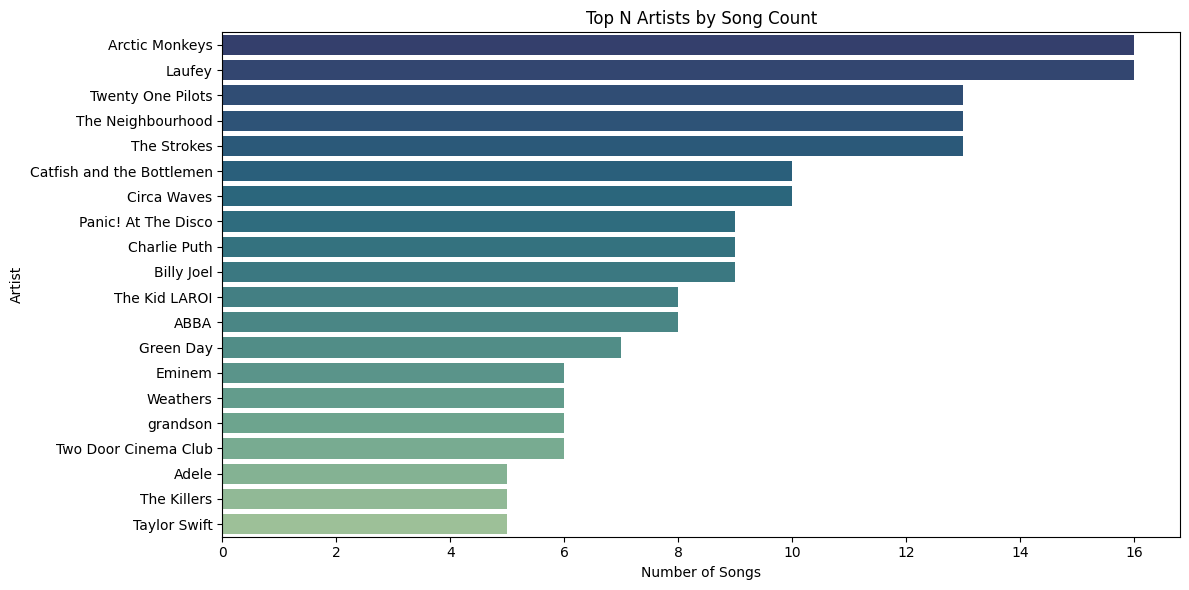

In [4]:
top_number = 20
top_artists_all = df['Artist Name(s)'].value_counts()
top_artists = top_artists_all.head(top_number)

plt.figure(figsize=(12,6))
sns.barplot(x = top_artists.values, y = top_artists.index, hue=top_artists.index, palette='crest_r', legend = False)
plt.title('Top N Artists by Song Count')
plt.xlabel('Number of Songs')
plt.ylabel('Artist')
plt.tight_layout()
plt.show()

## Artist Eclecticness

Rather than asking which artists appear most, this chart asks how many artists appear exactly once, 
twice, three times, and so on. It is a frequency-of-frequencies plot.

A playlist dominated by the leftmost bar (artists appearing only once) suggests broad, eclectic taste - 
many different artists sampled lightly. A playlist where the weight sits further right suggests deeper 
investment in a smaller number of artists. 
Note that the x-axis only shows values that actually exist in the data, 
so gaps simply mean no artist appears exactly that many times.

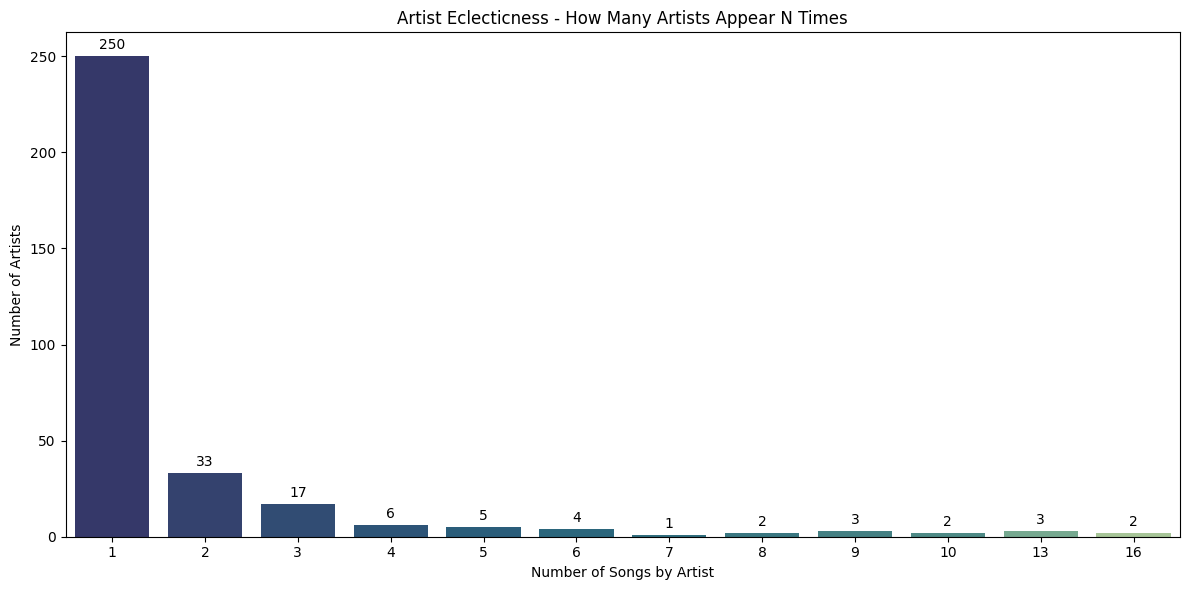

In [5]:
freq_artists = top_artists_all.value_counts().sort_index()

plt.figure(figsize=(12, 6))
sns.barplot(x=freq_artists.index, y=freq_artists.values, hue = freq_artists.index, palette='crest_r', legend = False)
plt.title('Artist Eclecticness - How Many Artists Appear N Times')
plt.xlabel('Number of Songs by Artist')
plt.ylabel('Number of Artists')
ax = plt.gca()
for container in ax.containers:
    ax.bar_label(container, padding=3)
plt.tight_layout()
plt.show()

## Release Year Distribution

This histogram shows how songs are distributed across release periods. 
Each bar represents a 5-year window, and the height shows how many tracks in the playlist 
were released during that period.

This can reveal whether a listener gravitates towards contemporary releases, 
a specific era (e.g. 1970s classic rock, early 2000s pop), or has a broad spread across decades. 
A right-skewed distribution (heavier on recent years) is common for active Spotify users 
whose playlists grow alongside new releases.

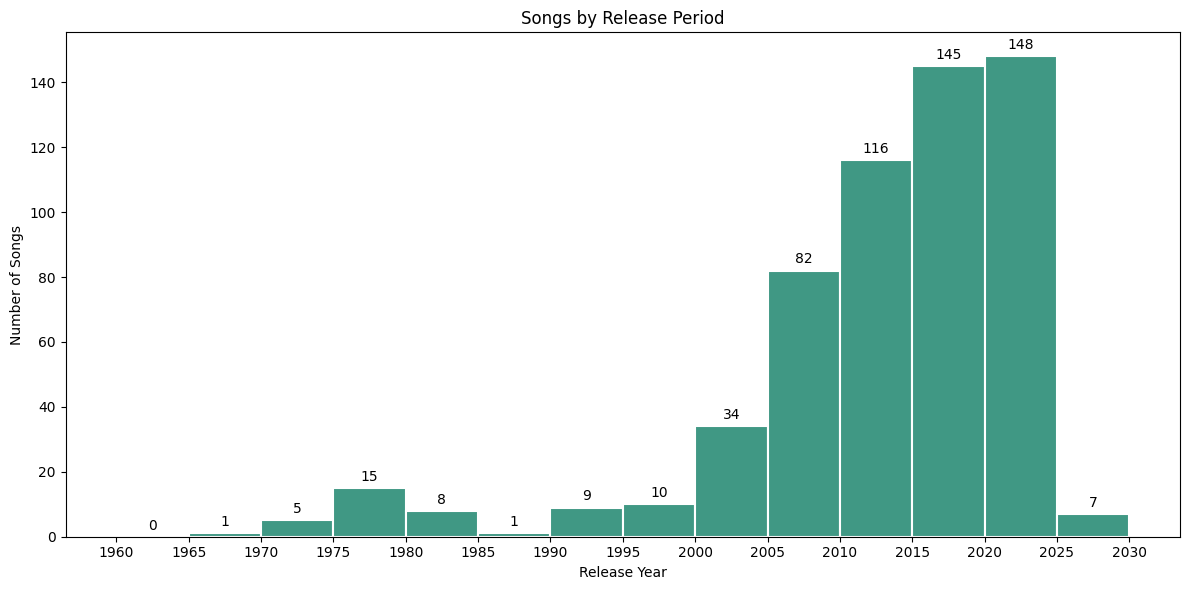

In [6]:
df['Release Date'] = pd.to_datetime(df['Release Date'], format='mixed')
release_year = df['Release Date'].dt.year

decade_bins = range(1960, 2035, 5)

plt.figure(figsize=(12, 6))
sns.histplot(x=release_year, bins=decade_bins, color="#00765B", edgecolor='white', linewidth=1.5)
plt.title('Songs by Release Period')
plt.xlabel('Release Year')
plt.ylabel('Number of Songs')
plt.xticks(range(1960, 2035, 5))
ax = plt.gca()
for container in ax.containers:
    ax.bar_label(container, padding=3)
plt.tight_layout()
plt.show()

## Genre Distribution

Spotify assigns genre tags at the artist level rather than the track level, 
and many tracks carry multiple genres stored as a comma-separated string. 
To count genres meaningfully, the data is first split so each genre occupies its own row, 
then counted across the full dataset.

**Note:** approximately half the tracks in a typical Exportify export have no genre data. 
This is a Spotify API limitation - not all artists are tagged - so the genre chart reflects 
only the portion of the playlist with available genre information. 

Later on, however, the project aims to estimate the genres of such tracks with no genre data, but these results may have varying accuracy.

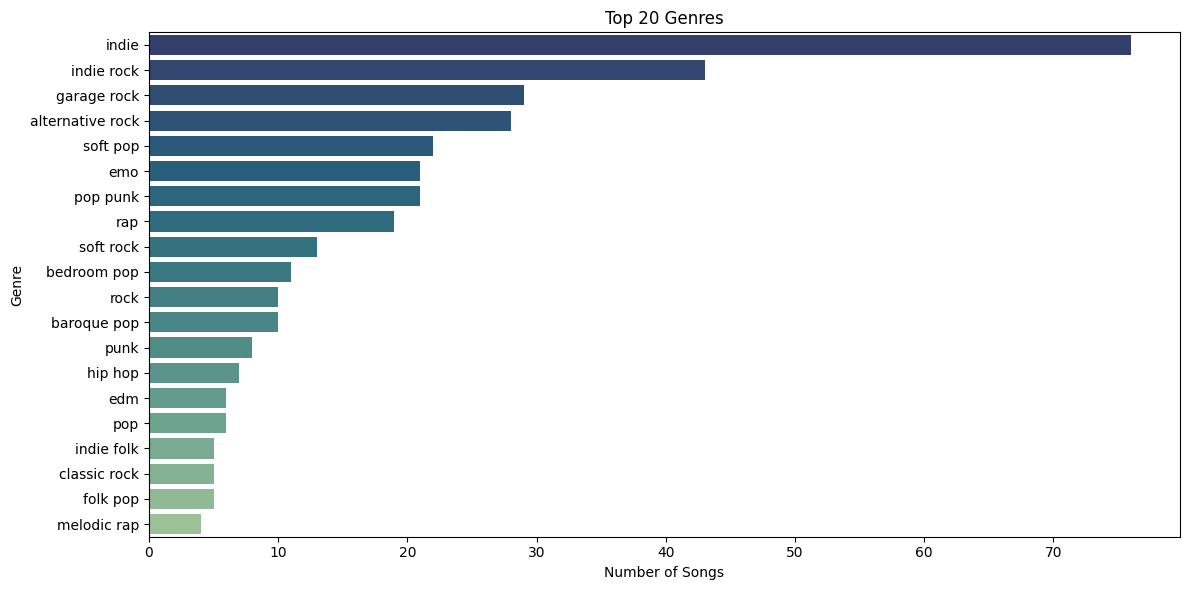

In [7]:
all_genres = df['Genres'].dropna().str.split(',').explode().str.strip()
all_genres.value_counts().head(20)

top_genres = all_genres.value_counts().head(20)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_genres.values, y=top_genres.index, palette='crest_r', hue = top_genres.index, legend = False)
plt.title('Top 20 Genres')
plt.xlabel('Number of Songs')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

## Popularity Distribution

Spotify assigns each track a popularity score from 0 to 100, calculated algorithmically 
based on total play count weighted heavily towards recent streams. 
It is a relative, time-sensitive measure - a score of 80 means the track is more streamed 
than roughly 80% of all tracks on Spotify right now, not historically.

Two things to be aware of when reading this chart:
- The spike at 0 does not necessarily indicate obscure tracks. 
Older songs that were once popular but are no longer being actively streamed will score near 0 
regardless of their cultural significance.
- A playlist skewed towards high popularity scores suggests mainstream listening habits; 
a flatter or left-leaning distribution suggests a preference for less commercially dominant music.

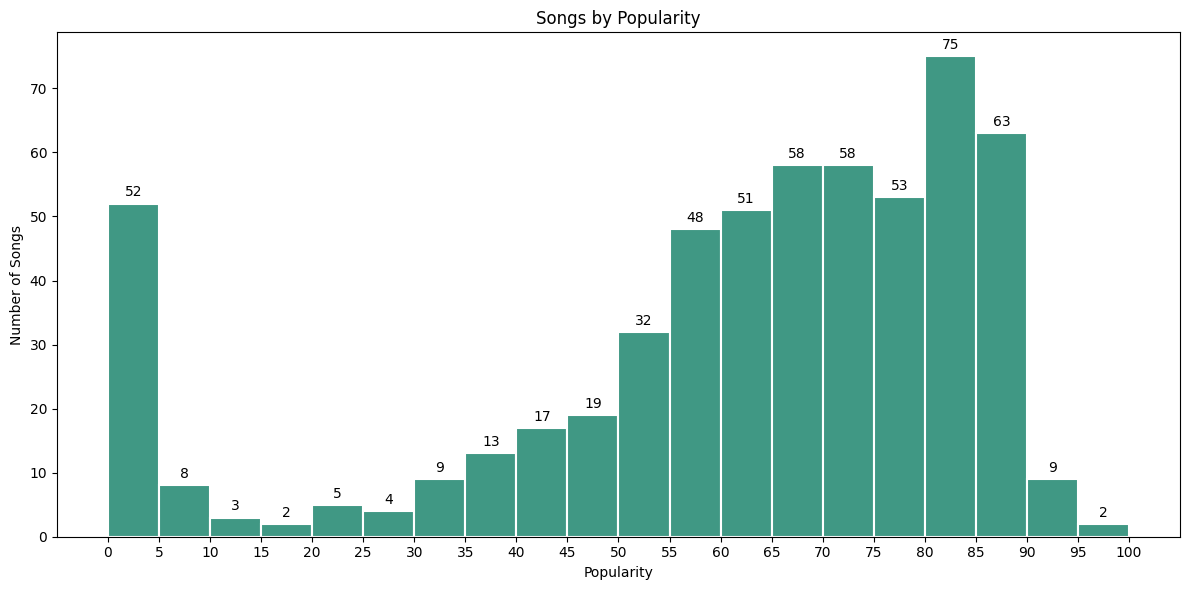

In [8]:
popularity_bins = range(0,101,5)

plt.figure(figsize=(12,6))
sns.histplot(x = df['Popularity'], bins=popularity_bins, color="#00765B", edgecolor = 'white', linewidth = 1.5)
plt.title('Songs by Popularity')
plt.xlabel('Popularity')
plt.ylabel('Number of Songs')
plt.xticks(popularity_bins)
ax = plt.gca()
for container in ax.containers:
    ax.bar_label(container, padding=3)
plt.tight_layout()
plt.show()

## Track Duration

This section looks at how long the tracks in the playlist are. 
Duration is converted from milliseconds (as stored by Spotify) to minutes for readability.

Most commercially released songs cluster between 2.5 and 4.5 minutes, 
reflecting standard radio-friendly lengths. 
A right skew (a long tail of longer tracks) is common in playlists that include 
classic rock epics, extended album cuts, or live recordings. 
The accompanying chart lists the longest tracks individually.

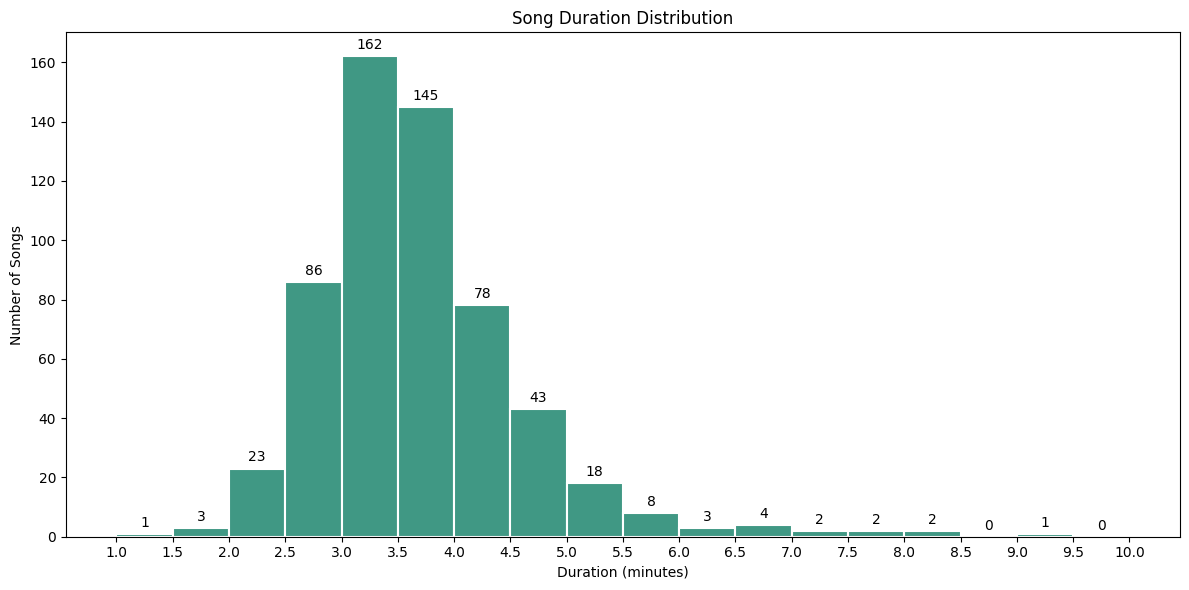

In [9]:
duration_min = df['Duration (ms)'] / 60000
duration_bins = np.arange(1, 10.5, 0.5)

plt.figure(figsize=(12, 6))
sns.histplot(x=duration_min, bins=duration_bins, color="#00765B", edgecolor='white', linewidth=1.5)
plt.title('Song Duration Distribution')
plt.xlabel('Duration (minutes)')
plt.ylabel('Number of Songs')
plt.xticks(duration_bins)
ax = plt.gca()
for container in ax.containers:
    ax.bar_label(container, padding=3)
plt.tight_layout()
plt.show()

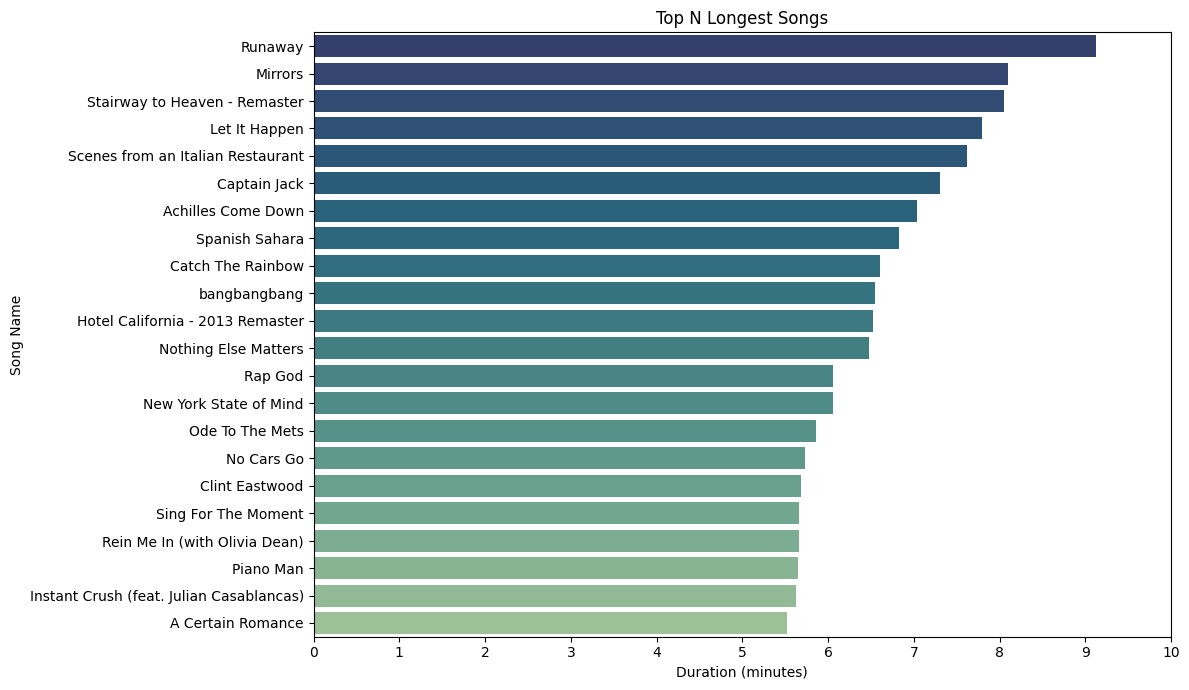

In [10]:
longest_song_number = 22
longest_songs = df.sort_values('Duration (ms)', ascending=False).head(longest_song_number)
longest_songs = longest_songs.copy()
longest_songs['Duration (min)'] = longest_songs['Duration (ms)'] / 60000

plt.figure(figsize=(12, 7))
sns.barplot(x=longest_songs['Duration (min)'], y=longest_songs['Track Name'], 
            hue=longest_songs['Track Name'], palette='crest_r', legend=False)
plt.title('Top N Longest Songs')
plt.xlabel('Duration (minutes)')
plt.ylabel('Song Name')
plt.xticks(range(0,11,1))
plt.tight_layout()
plt.show()

## Audio Feature Distributions

Spotify computes a set of continuous audio features for every track using acoustic analysis. 
Most features are normalised to a 0-1 scale. Here is what each one measures:

- **Tempo** - the estimated beats per minute (BPM) of the track.
- **Acousticness** - the likelihood that a track was recorded with acoustic instruments. A score of 1.0 means highly acoustic.
- **Instrumentalness** - the likelihood that a track contains no vocals. Most vocal music scores very close to 0.
- **Liveness** - the probability that the track was performed live, based on the presence of audience noise.
- **Valence** - the musical positiveness of a track. High valence sounds happy or euphoric. Low valence sounds sad or angry.
- **Speechiness** - the presence of spoken words. Scores above 0.66 suggest spoken word content. Scores between 0.33 and 0.66 suggest tracks mixing music and speech (e.g. rap). Most music scores below 0.33.
- **Loudness** - the average loudness of a track in decibels (dB). Unlike the other features, this is not normalised - typical values range from around -20 dB (quiet) to near 0 dB (very loud).
- **Energy** - a perceptual measure of intensity and activity. High energy tracks feel fast, loud, and noisy. Low energy tracks feel slow and quiet.
- **Danceability** - how suitable a track is for dancing, based on tempo, rhythm stability, beat strength, and regularity. Higher = more danceable.

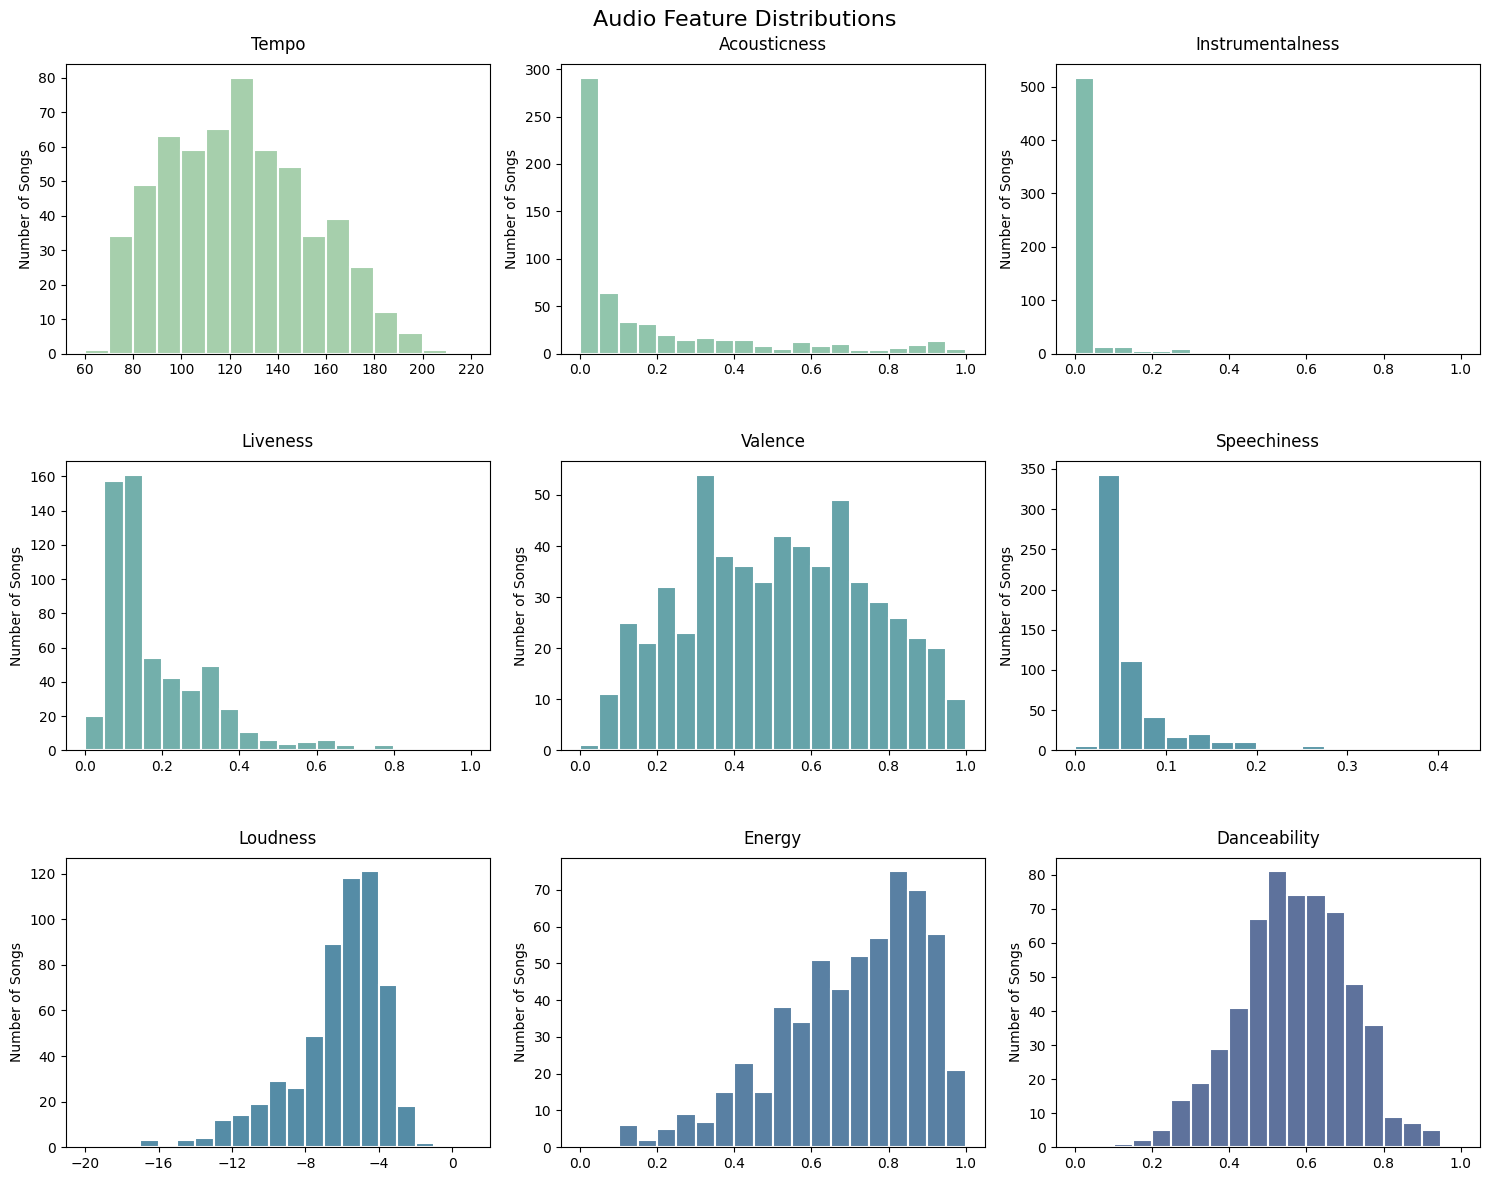

In [27]:
features = ['Tempo', 'Acousticness', 'Instrumentalness', 'Liveness', 'Valence', 'Speechiness', 'Loudness', 'Energy', 'Danceability']
colours = sns.color_palette('crest', 9)

feature_settings = {
    'Tempo':            {'bins': np.arange(60, 221, 10),   'ticks': np.arange(60, 221, 20)},
    'Acousticness':     {'bins': np.arange(0, 1.05, 0.05), 'ticks': np.arange(0, 1.1, 0.2)},
    'Instrumentalness': {'bins': np.arange(0, 1.05, 0.05), 'ticks': np.arange(0, 1.1, 0.2)},
    'Liveness':         {'bins': np.arange(0, 1.05, 0.05), 'ticks': np.arange(0, 1.1, 0.2)},
    'Valence':          {'bins': np.arange(0, 1.05, 0.05), 'ticks': np.arange(0, 1.1, 0.2)},
    'Speechiness':      {'bins': np.arange(0, 0.45, 0.025),'ticks': np.arange(0, 0.45, 0.1)},
    'Loudness':         {'bins': np.arange(-20, 2, 1),     'ticks': np.arange(-20, 2, 4)},
    'Energy':           {'bins': np.arange(0, 1.05, 0.05), 'ticks': np.arange(0, 1.1, 0.2)},
    'Danceability':     {'bins': np.arange(0, 1.05, 0.05), 'ticks': np.arange(0, 1.1, 0.2)},
}

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, feature in enumerate(features):
    settings = feature_settings[feature]
    sns.histplot(df[feature], ax=axes[i], bins=settings['bins'],
                 color=colours[i], edgecolor='white', linewidth=1.5)
    axes[i].set_title(feature, pad=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Number of Songs')
    axes[i].set_xticks(settings['ticks'])

fig.suptitle('Audio Feature Distributions', fontsize=16)
plt.tight_layout(h_pad=4)
plt.show()

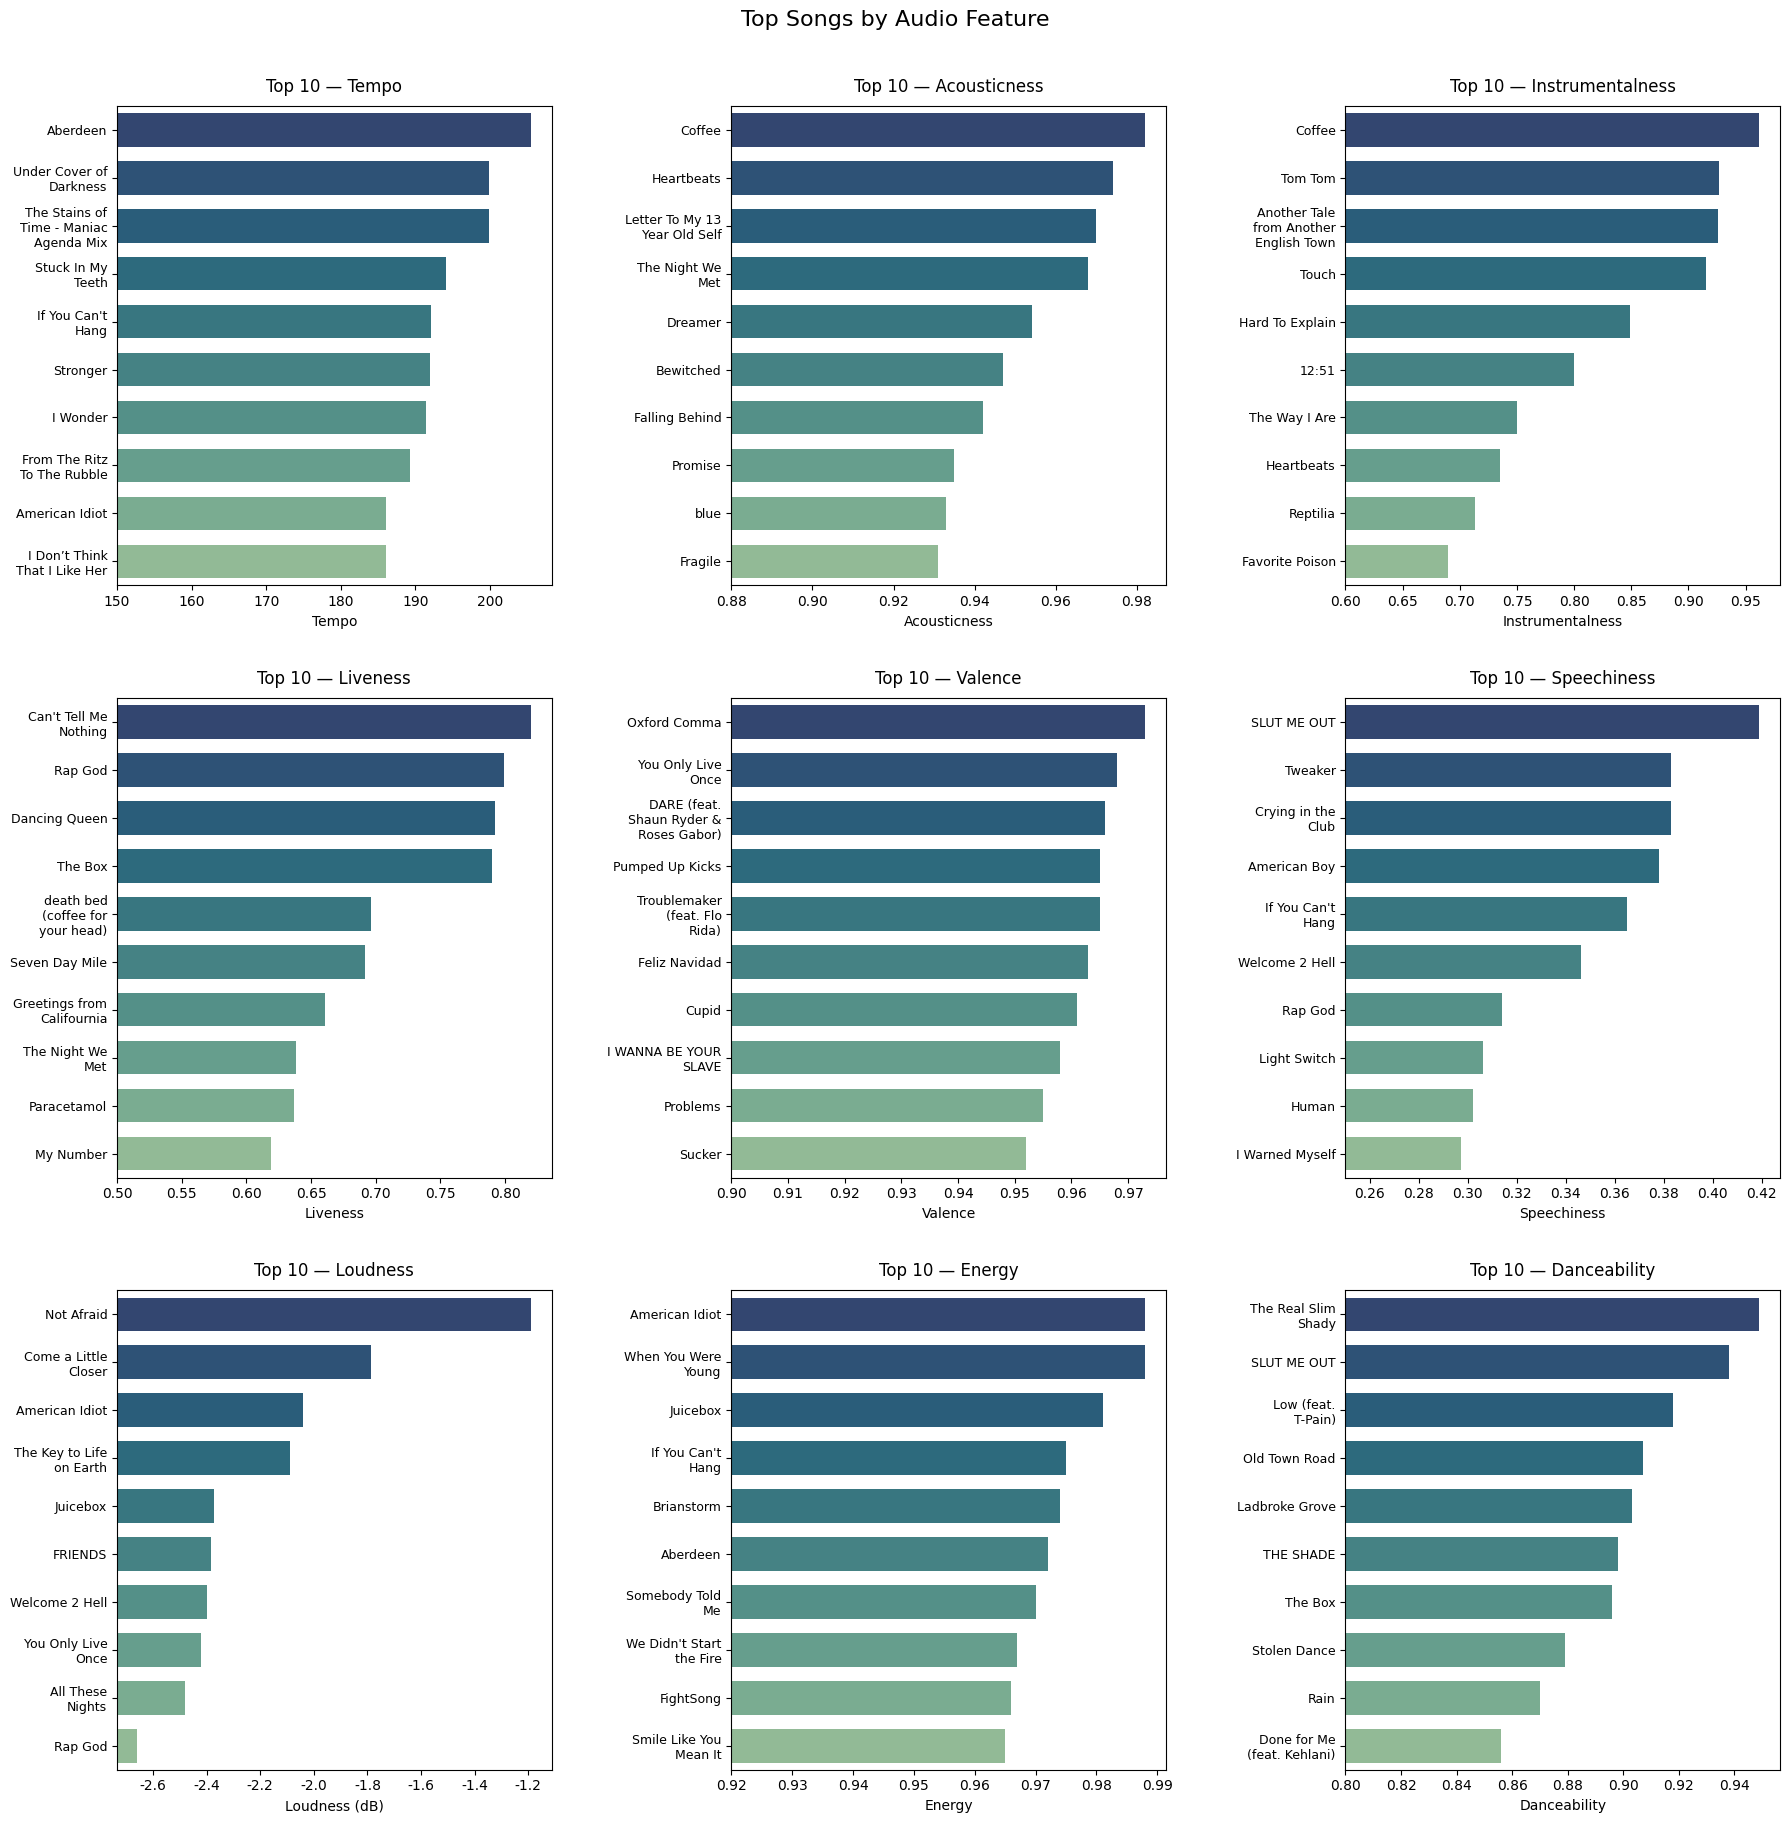

In [61]:
import textwrap

feature_song_number = 10

x_starts = {
    'Tempo':            150,
    'Acousticness':     0.88,
    'Instrumentalness': 0.6,
    'Liveness':         0.5,
    'Valence':          0.9,
    'Speechiness':      0.25,
    'Energy':           0.92,
    'Danceability':     0.8,
}

fig, axes = plt.subplots(3, 3, figsize=(18, 18))
axes = axes.flatten()

for i, feature in enumerate(features):
    top_songs = df.sort_values(feature, ascending=False).head(feature_song_number).copy()
    top_songs['Display Name'] = top_songs['Track Name'].apply(lambda x: textwrap.fill(x, width=15))

    if feature == 'Loudness':
        min_val = top_songs[feature].min()
        max_val = top_songs[feature].max()
        range_val = max_val - min_val
        baseline = min_val - range_val * 0.05

        top_songs['Shifted'] = top_songs[feature] - baseline
        shifted_max = max_val - baseline

        sns.barplot(x=top_songs['Shifted'], y=top_songs['Display Name'],
                    hue=top_songs['Display Name'], palette='crest_r',
                    legend=False, ax=axes[i], width=0.7)

        tick_start = np.floor(min_val / 0.2) * 0.2
        tick_positions_db = np.arange(tick_start, max_val + 0.15, 0.2)
        tick_positions_shifted = tick_positions_db - baseline
        valid = tick_positions_shifted >= 0
        axes[i].set_xticks(tick_positions_shifted[valid])
        axes[i].set_xticklabels([f'{v:.1f}' for v in tick_positions_db[valid]])
        axes[i].set_xlim(0, shifted_max * 1.05)
        axes[i].set_xlabel('Loudness (dB)')
    else:
        start = x_starts[feature]
        data_max = top_songs[feature].max()
        padding = (data_max - start) * 0.05
        sns.barplot(x=top_songs[feature], y=top_songs['Display Name'],
                    hue=top_songs['Display Name'], palette='crest_r',
                    legend=False, ax=axes[i], width=0.7)
        axes[i].set_xlim(start, data_max + padding)
        axes[i].set_xlabel(feature)

    axes[i].set_title(f'Top {feature_song_number} — {feature}', pad=10, fontsize=12)
    axes[i].set_ylabel('')
    axes[i].tick_params(axis='y', labelsize=9)

fig.suptitle('Top Songs by Audio Feature', fontsize=16, y=1.01)
plt.tight_layout(h_pad=3, w_pad=4)
plt.show()